In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

DIRPATH_REPO = Path().resolve().parents[1]
print(DIRPATH_REPO)

/home/nnovikov/repo/sim_data_analyzer


In [62]:
dirpath_data = DIRPATH_REPO / 'dev_scratch/data_proc/a1_lfp_30s_0'

fpath_rates = dirpath_data / 'a1_lfp_30s_0_rates_dt_0.001.nc'
fpath_mask = dirpath_data / 'oevent_mask' / 'exp1__csd__alpha__t_5_30__y_0_3000__oevcfg_default.nc'

# Load raes and OEvent mask
rates = xr.load_dataarray(fpath_rates)
oev_mask = xr.load_dataarray(fpath_mask)

# Match time coords
rates = rates.sel(time=slice(oev_mask.time[0], None))
oev_mask = oev_mask.interp(time=rates.time, method='nearest').astype(bool)

In [63]:
Y_SIZE = 2000
LAYER_Y_NORM = {
    '1': [0.00, 0.05], '2': [0.05, 0.08], '3': [0.08, 0.475], '4': [0.475, 0.625],
    '5A': [0.625, 0.667], '5B': [0.667, 0.775], '6': [0.775, 1], 'thal': [1.2, 1.4]
}
LAYER_Y = {layer: [a * Y_SIZE, b * Y_SIZE]
           for layer, (a, b) in LAYER_Y_NORM.items()}

def select_y_by_layers(data, layer_bounds, layers):
    yy = data['y'].values
    y_mask = np.zeros_like(yy, dtype=bool)

    for layer in layers:
        if layer not in layer_bounds:
            raise KeyError(f"Unknown layer '{layer}'. Available: {list(layer_bounds.keys())}")
        y0, y1 = layer_bounds[layer]
        y_mask |= (yy >= y0) & (yy <= y1)

    data_sel = data.sel(y=yy[y_mask])
    return data_sel

In [64]:
# Select depth range
layers_sel = ['2', '3']
oev_mask_ysel = select_y_by_layers(oev_mask, LAYER_Y, layers_sel)

# Percentage of in-burst time bins at every depth
for y in oev_mask_ysel.y.values:
    print(int(y), oev_mask_ysel.sel(y=y).mean().item())

100 0.24396
200 0.18004
300 0.1468
400 0.13268
500 0.16824
600 0.27348
700 0.1974
800 0.17612
900 0.14564


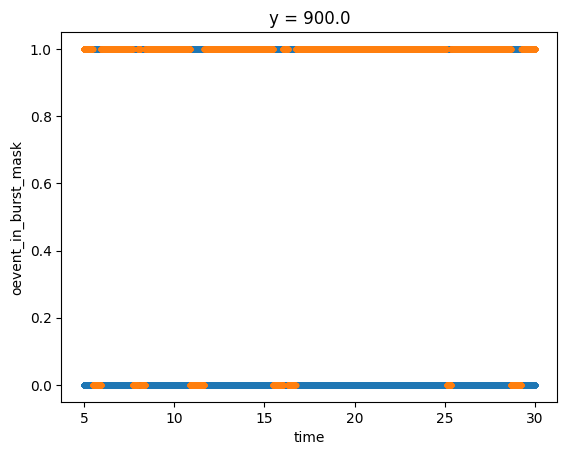

In [82]:
oev_mask_ysel.sel(y=y).plot(marker='.', linewidth=0)
(~oev_mask_ysel.sel(y=y)).plot(marker='.', linewidth=0)

(-1.0, 2.0)

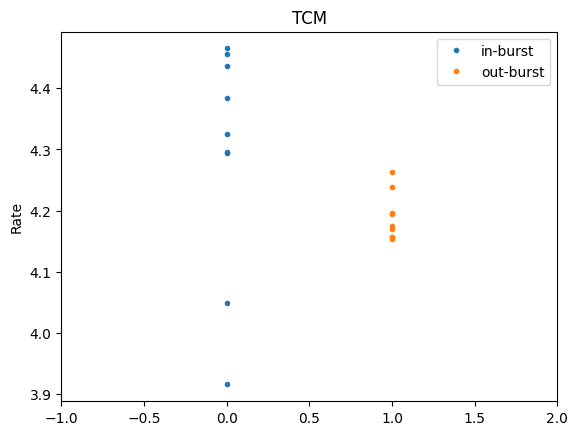

In [92]:
pop = 'TCM'
rr = rates.sel(pop=pop)

rb, rnb = [], []
for y in oev_mask_ysel.y.values:
    mask_t = oev_mask_ysel.sel(y=y).values
    #print(int(y), mask_t.sum())
    rb.append(rr[mask_t].mean().item())
    rnb.append(rr[~mask_t].mean().item())

plt.figure()
plt.plot([0] * len(rb), rb, '.', label='in-burst')
plt.plot([1] * len(rnb), rnb, '.', label='out-burst')
plt.legend()
plt.ylabel('Rate')
plt.title(pop)
plt.xlim(-1, 2)

In [3]:
x = np.array([0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0])
x

array([0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0])